In [193]:
import pandas as pd

In [194]:
import pandas as pd
df=pd.read_csv("data/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In this section, we analyze how Netflix expanded its content catalog overtime, focusing on movies and TV shows 

In [195]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [196]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [197]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [198]:
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [199]:
df.groupby('type')['release_year'].value_counts()

type     release_year
Movie    2017            767
         2018            767
         2016            658
         2019            633
         2020            517
                        ... 
TV Show  1963              1
         1974              1
         1945              1
         1925              1
         1972              1
Name: count, Length: 119, dtype: int64

In [200]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_year']=df['date_added'].dt.year
df.groupby('type')['date_year'].value_counts().groupby(level=0).head(10)

type     date_year
Movie    2019.0       1424
         2020.0       1284
         2018.0       1237
         2021.0        993
         2017.0        839
         2016.0        253
         2015.0         56
         2014.0         19
         2011.0         13
         2013.0          6
TV Show  2020.0        594
         2019.0        575
         2021.0        505
         2018.0        388
         2017.0        325
         2016.0        165
         2015.0         17
         2014.0          4
         2013.0          4
         2008.0          1
Name: count, dtype: int64

In [201]:
import matplotlib.pyplot as plt

<function matplotlib.pyplot.show(close=None, block=None)>

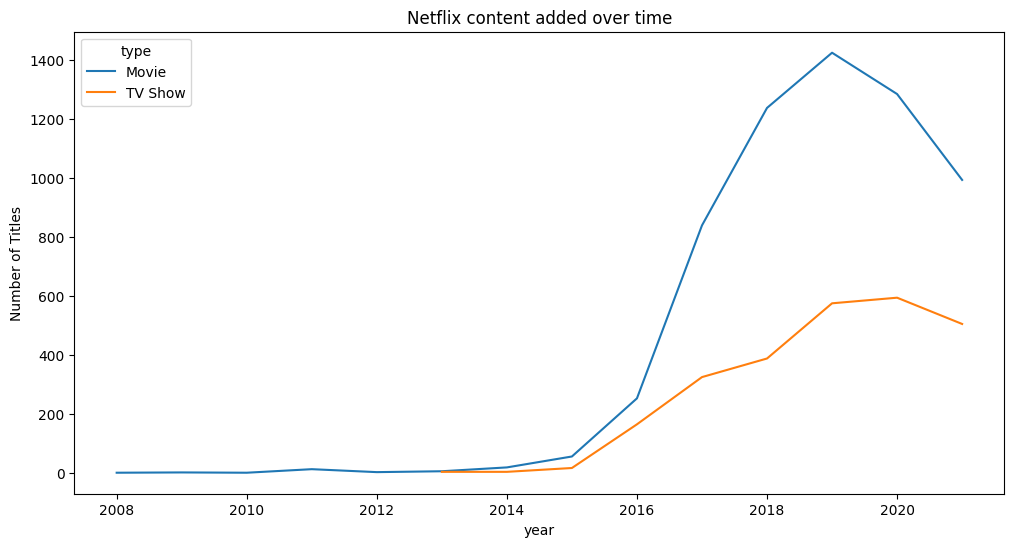

In [202]:
trend=df.groupby(['date_year','type']).size().unstack()
trend.plot(figsize=(12,6))
plt.title('Netflix content added over time')
plt.xlabel('year')
plt.ylabel('Number of Titles')
plt.savefig(
    'figures/netflix_content_added_over_time.png',
    bbox_inches='tight'
)
plt.show

From 2016, movie and tv show experenced rapid expand. Movie still holds the dominate position. TV show starts growing fast after 2016 and reach the peak.
### Key Findings

- Netflix experienced aggressive catalog expansion between 2016 and 2020.
- Movies continue to dominate the platform overall, suggesting that films remain the foundation of Netflix’s content library.
- TV Shows demonstrated particularly strong growth after 2018, potentially reflecting Netflix’s increasing focus on long-term user engagement and binge-watching behavior.

## Business Question 
- How has Netflix evolve into a global platform?

## Methodology

- To investigate Netflix’s global expansion strategy, the analysis focuses on country-level content distribution and temporal growth trends.

Missing values in the `country` column were excluded only for country-specific analyses. Content rankings were first examined to identify the major contributing countries and regions, followed by trend analysis over time for the top-performing countries.

In [203]:
df_country=df.dropna(subset=['country'])
df_country['country'].isnull().sum()
df_country['country'].value_counts().head(20)

country
United States                    2818
India                             972
United Kingdom                    419
Japan                             245
South Korea                       199
Canada                            181
Spain                             145
France                            124
Mexico                            110
Egypt                             106
Turkey                            105
Nigeria                            95
Australia                          87
Taiwan                             81
Indonesia                          79
Brazil                             77
United Kingdom, United States      75
Philippines                        75
United States, Canada              73
Germany                            67
Name: count, dtype: int64

In [204]:
top_countries=df_country['country'].value_counts().head(20)

## Visualization

Text(0, 0.5, 'Country')

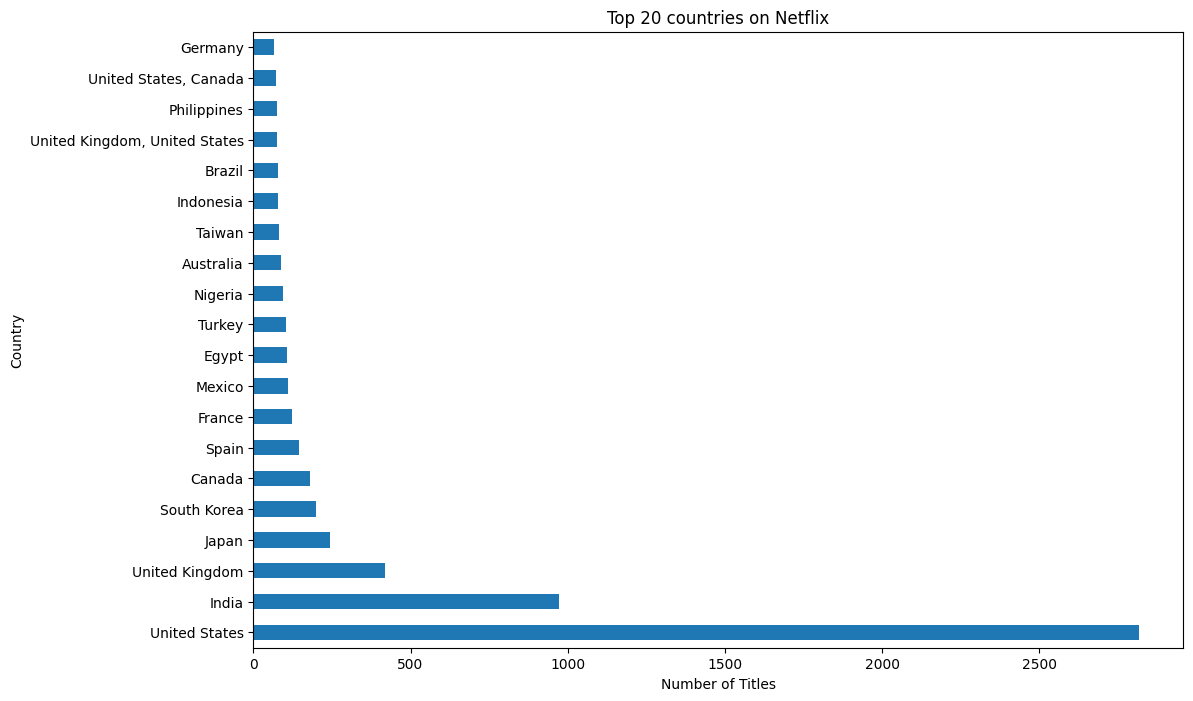

In [205]:
top_countries.plot(kind='barh',figsize=(12,8))
plt.title('Top 20 countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')


- ## Key Findings

- The United States contributes the largest share of Netflix titles by a substantial margin, with the number of U.S. titles exceeding more than twice that of India, the second-largest contributor.
- The United Kingdom ranks third, although its content volume is considerably lower than that of India.
- Countries ranked between 10th and 20th show relatively modest differences in title counts, suggesting a more balanced distribution among emerging international markets.
- Overall, the findings indicate that while Netflix has developed an increasingly international catalog, the platform still remains strongly dominated by U.S. productions.
- The growing presence of countries such as South Korea, Japan, Spain, and Turkey may reflect Netflix’s continued efforts to diversify its global content strategy and expand regional audience engagement.

### Netflix Global Content Strategy Analysis


## Asian Market Expansion Analysis

## Business Question

Has Netflix increasingly expanded its investment in Asian content markets over time?

## Hypothesis

Netflix has significantly increased Asian content offerings, particularly from countries such as South Korea, India, Japan, and Taiwan, as part of its global content diversification strategy.

In [206]:
asian_countries=['India','South Korea','Japan','Taiwan']
df_asia=df_country[df_country['country'].isin(asian_countries)]



In [207]:
df_asia.groupby(['date_year','country']).size().unstack()

country,India,Japan,South Korea,Taiwan
date_year,,,,
2015.0,NaN,1.0,NaN,NaN
2016.0,10.0,16.0,9.0,24.0
2017.0,141.0,27.0,36.0,11.0
2018.0,333.0,35.0,25.0,8.0
2019.0,203.0,57.0,53.0,20.0
2020.0,189.0,61.0,46.0,10.0
2021.0,95.0,44.0,26.0,8.0


In [208]:
asia_trend=df_asia.groupby(['date_year','country']).size().unstack()

## Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

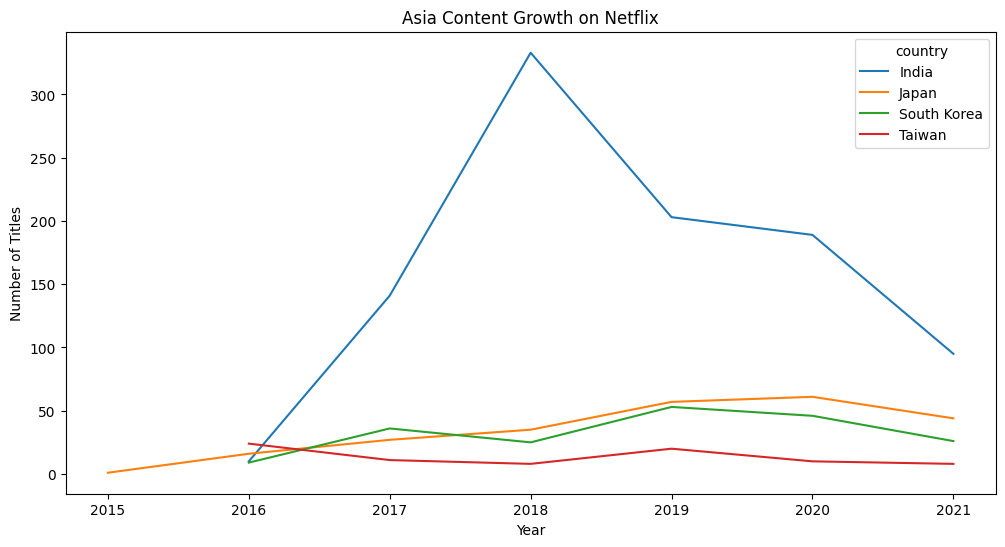

In [209]:
asia_trend.plot(figsize=(12,6))
plt.title('Asia Content Growth on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show

### Key Findings

- Indian content experienced substantial growth after 2016 and reached a peak around 2018, suggesting Netflix’s increasing investment in the Indian entertainment market.
- Japanese and South Korean titles demonstrated relatively stable and consistent growth over time. In particular, the continued expansion of Korean content may reflect Netflix’s strategic focus on globally popular K-content and regional audience engagement.
- Taiwanese content remained comparatively limited in scale throughout the observed period, with annual additions remaining relatively stable at lower levels.
- Overall, the findings suggest that Netflix’s Asian content strategy has become increasingly diversified, with India, Japan, and South Korea emerging as key regional contributors to the platform’s international expansion.

## Business Question 
- How has international content collaboration evolved on Netflix over time?
## Hypothesis
- The growth of multinational co-productions may reflect Netflix’s increasing globalization and cross-regional content strategy.

In [210]:
df_country['is_coproduction']=df_country['country'].str.contains(',')
coproduction_trend=df_country.groupby(['date_year','is_coproduction']).size().unstack()
coproduction_trend

is_coproduction,False,True
date_year,,
2008.0,2.0,NaN
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,11.0,2.0
2012.0,2.0,1.0
2013.0,8.0,2.0
2014.0,16.0,7.0
2015.0,58.0,12.0
2016.0,329.0,70.0


## Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

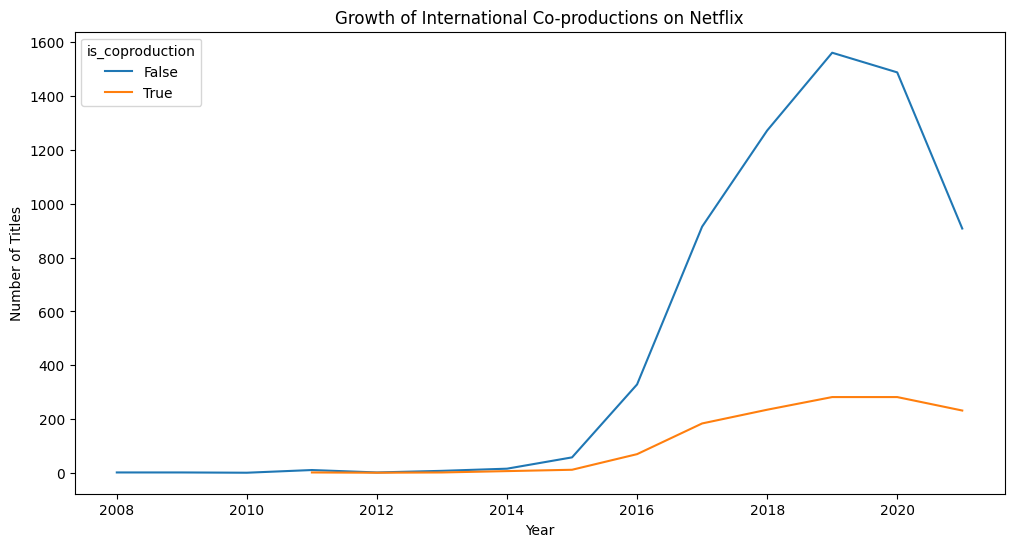

In [211]:
coproduction_trend.plot(figsize=(12,6))
plt.title('Growth of International Co-productions on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show

### Visualization Consideration

Although the comparison between co-productions and non-co-productions provides a general overview of Netflix’s catalog composition, this visualization may not effectively capture the globalization trend of co-productions themselves.

Because independently produced titles substantially outnumber multinational co-productions, the scale difference compresses the co-production trend visually and limits interpretability. Therefore, the globalization significance of co-productions should be examined independently rather than primarily through direct comparison with non-co-produced titles.

To better evaluate Netflix’s international collaboration strategy, a separate trend analysis focusing specifically on co-production growth and proportional change over time may provide more meaningful insights.

## proportion trend over time 

# title number each year

In [212]:
coproduction_share=coproduction_trend[True]/coproduction_trend.sum(axis=1)

In [213]:
total_titles=df_country.groupby('date_year').size()
total_titles

date_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      70
2016.0     399
2017.0    1099
2018.0    1507
2019.0    1843
2020.0    1770
2021.0    1140
dtype: int64

In [214]:
coproduction_titles=df_country[df_country['is_coproduction']].groupby('date_year').size()
coproduction_titles

date_year
2011.0      2
2012.0      1
2013.0      2
2014.0      7
2015.0     12
2016.0     70
2017.0    184
2018.0    235
2019.0    282
2020.0    282
2021.0    232
dtype: int64

In [215]:
coproduction_share=coproduction_titles/total_titles
coproduction_share

date_year
2008.0         NaN
2009.0         NaN
2010.0         NaN
2011.0    0.153846
2012.0    0.333333
2013.0    0.200000
2014.0    0.304348
2015.0    0.171429
2016.0    0.175439
2017.0    0.167425
2018.0    0.155939
2019.0    0.153011
2020.0    0.159322
2021.0    0.203509
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

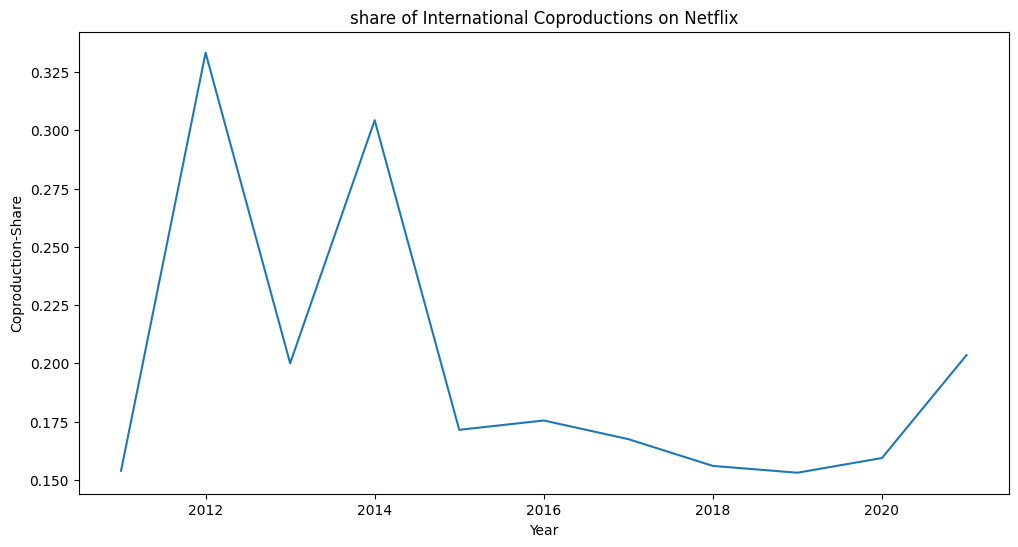

In [216]:
plt.figure(figsize=(12,6))
coproduction_share.plot()
plt.title('share of International Coproductions on Netflix')
plt.xlabel('Year')
plt.ylabel('Coproduction-Share')
plt.savefig('figures/share_of_coproduction.png',bbox_inches='tight')
plt.show

## Key Findings

Although international co-productions increased in absolute numbers after 2015, the proportional share of co-produced titles did not demonstrate a clear and sustained upward trend over time.

The co-production share fluctuated across years, with local peaks observed around 2012 and 2014, followed by a gradual decline after 2016 before recovering slightly in 2021. These results suggest that, within the current dataset, multinational co-productions alone may not provide sufficient evidence to conclusively support a strong globalization trend in Netflix’s content strategy.

### Genre and country analysis
## Business question 
How do genre differ across countries, and what content categories may deserve stronger future investment in different markets?
## Analytical goal 
This section exams the relationship between country and genre to identify regional content patterns. The goal is to move beyond country level counts and explore what kinds of content different markets contribute to Netflix's catalog.

In [217]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'date_year'],
      dtype='str')

### Genre Distribution Across Major Netflix Markets

In this section, I analyze the genre composition of Netflix content across several major countries, including the United States, India, Japan, South Korea, Canada, and the United Kingdom.

The goal is to identify differences in content specialization, genre concentration, and regional storytelling preferences.

In [218]:
import pandas as pd
df=pd.read_csv ("data/netflix_titles.csv")
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce') 
df['date_year']=df['date_added'].dt.year
df.head(50)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0


In [219]:
genre_country_df=df[['country','listed_in','type','duration','rating','date_year']]
genre_country_df.head(50)

,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,"International TV Shows, TV Dramas, TV Mysteries",TV Show,2 Seasons,TV-MA,2021.0
2,NaN,"Crime TV Shows, International TV Shows, TV Act...",TV Show,1 Season,TV-MA,2021.0
3,NaN,"Docuseries, Reality TV",TV Show,1 Season,TV-MA,2021.0
4,India,"International TV Shows, Romantic TV Shows, TV ...",TV Show,2 Seasons,TV-MA,2021.0
5,NaN,"TV Dramas, TV Horror, TV Mysteries",TV Show,1 Season,TV-MA,2021.0
6,NaN,Children & Family Movies,Movie,91 min,PG,2021.0
7,"United States, Ghana, Burkina Faso, United Kin...","Dramas, Independent Movies, International Movies",Movie,125 min,TV-MA,2021.0
8,United Kingdom,"British TV Shows, Reality TV",TV Show,9 Seasons,TV-14,2021.0
9,United States,"Comedies, Dramas",Movie,104 min,PG-13,2021.0


In [220]:
df['date_year'].value_counts().sort_index()

date_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

In [221]:
df['country'].isna().sum()

np.int64(831)

In [222]:

df['listed_in'].head(50)

0                                         Documentaries
1       International TV Shows, TV Dramas, TV Mysteries
2     Crime TV Shows, International TV Shows, TV Act...
3                                Docuseries, Reality TV
4     International TV Shows, Romantic TV Shows, TV ...
5                    TV Dramas, TV Horror, TV Mysteries
6                              Children & Family Movies
7      Dramas, Independent Movies, International Movies
8                          British TV Shows, Reality TV
9                                      Comedies, Dramas
10    Crime TV Shows, Docuseries, International TV S...
11    Crime TV Shows, International TV Shows, TV Act...
12                         Dramas, International Movies
13                   Children & Family Movies, Comedies
14         British TV Shows, Crime TV Shows, Docuseries
15                               TV Comedies, TV Dramas
16                  Documentaries, International Movies
17    Crime TV Shows, Spanish-Language TV Shows,

In [223]:
genre_country_df.head(10)

,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,"International TV Shows, TV Dramas, TV Mysteries",TV Show,2 Seasons,TV-MA,2021.0
2,NaN,"Crime TV Shows, International TV Shows, TV Act...",TV Show,1 Season,TV-MA,2021.0
3,NaN,"Docuseries, Reality TV",TV Show,1 Season,TV-MA,2021.0
4,India,"International TV Shows, Romantic TV Shows, TV ...",TV Show,2 Seasons,TV-MA,2021.0
5,NaN,"TV Dramas, TV Horror, TV Mysteries",TV Show,1 Season,TV-MA,2021.0
6,NaN,Children & Family Movies,Movie,91 min,PG,2021.0
7,"United States, Ghana, Burkina Faso, United Kin...","Dramas, Independent Movies, International Movies",Movie,125 min,TV-MA,2021.0
8,United Kingdom,"British TV Shows, Reality TV",TV Show,9 Seasons,TV-14,2021.0
9,United States,"Comedies, Dramas",Movie,104 min,PG-13,2021.0


In [224]:
genre_country_df=genre_country_df.explode('listed_in')
genre_country_df.head(50)

,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,"International TV Shows, TV Dramas, TV Mysteries",TV Show,2 Seasons,TV-MA,2021.0
2,NaN,"Crime TV Shows, International TV Shows, TV Act...",TV Show,1 Season,TV-MA,2021.0
3,NaN,"Docuseries, Reality TV",TV Show,1 Season,TV-MA,2021.0
4,India,"International TV Shows, Romantic TV Shows, TV ...",TV Show,2 Seasons,TV-MA,2021.0
5,NaN,"TV Dramas, TV Horror, TV Mysteries",TV Show,1 Season,TV-MA,2021.0
6,NaN,Children & Family Movies,Movie,91 min,PG,2021.0
7,"United States, Ghana, Burkina Faso, United Kin...","Dramas, Independent Movies, International Movies",Movie,125 min,TV-MA,2021.0
8,United Kingdom,"British TV Shows, Reality TV",TV Show,9 Seasons,TV-14,2021.0
9,United States,"Comedies, Dramas",Movie,104 min,PG-13,2021.0


In [225]:
genre_country_df['listed_in'].value_counts().head(20)

listed_in
Dramas, International Movies                         362
Documentaries                                        359
Stand-Up Comedy                                      334
Comedies, Dramas, International Movies               274
Dramas, Independent Movies, International Movies     252
Kids' TV                                             220
Children & Family Movies                             215
Children & Family Movies, Comedies                   201
Documentaries, International Movies                  186
Dramas, International Movies, Romantic Movies        180
Comedies, International Movies                       176
Comedies, International Movies, Romantic Movies      152
Dramas                                               138
Dramas, International Movies, Thrillers              134
Action & Adventure, Dramas, International Movies     132
Action & Adventure                                   128
International TV Shows, TV Dramas                    121
Comedies, Dramas, Ind

In [226]:
genre_by_country=genre_country_df.groupby(['country','listed_in']).size()
genre_by_country.head(20)

country            listed_in                                                        
, France, Algeria  Dramas, Independent Movies, International Movies                     1
, South Korea      International TV Shows, TV Dramas                                    1
Argentina          Action & Adventure, Comedies, International Movies                   1
                   Action & Adventure, Horror Movies, International Movies              1
                   Children & Family Movies, Music & Musicals                           1
                   Classic & Cult TV, Crime TV Shows, International TV Shows            1
                   Comedies, Cult Movies, International Movies                          2
                   Comedies, International Movies                                       1
                   Comedies, International Movies, Music & Musicals                     1
                   Comedies, International Movies, Romantic Movies                      1
               

In [227]:
genre_country_df=df[['country','listed_in','type','duration','rating','date_year']].copy()
genre_country_df=genre_country_df.dropna(subset=['country','listed_in'])
genre_country_df['country']=genre_country_df['country'].str.split(', ')
genre_country_df['listed_in']=genre_country_df['listed_in'].str.split(', ')
genre_country_df=genre_country_df.explode('country')
genre_country_df=genre_country_df.explode('listed_in')
genre_country_df.head(20)



,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Dramas,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Mysteries,TV Show,2 Seasons,TV-MA,2021.0
4,India,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,Romantic TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,TV Comedies,TV Show,2 Seasons,TV-MA,2021.0
7,United States,Dramas,Movie,125 min,TV-MA,2021.0
7,United States,Independent Movies,Movie,125 min,TV-MA,2021.0
7,United States,International Movies,Movie,125 min,TV-MA,2021.0


In [228]:
pd.set_option('display.max_rows',100)
genre_country_df.head(20)

,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Dramas,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Mysteries,TV Show,2 Seasons,TV-MA,2021.0
4,India,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,Romantic TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,TV Comedies,TV Show,2 Seasons,TV-MA,2021.0
7,United States,Dramas,Movie,125 min,TV-MA,2021.0
7,United States,Independent Movies,Movie,125 min,TV-MA,2021.0
7,United States,International Movies,Movie,125 min,TV-MA,2021.0


In [229]:
genre_by_country=genre_country_df.groupby(['country','listed_in']).size().sort_values(ascending=False)
genre_by_country.head(50)

country         listed_in               
India           International Movies        864
United States   Dramas                      835
                Comedies                    680
India           Dramas                      662
United States   Documentaries               511
                Action & Adventure          404
                Independent Movies          390
                Children & Family Movies    390
India           Comedies                    323
United States   Thrillers                   292
                TV Comedies                 258
                TV Dramas                   232
                Romantic Movies             225
United Kingdom  British TV Shows            225
United States   Stand-Up Comedy             216
                Kids' TV                    214
France          International Movies        207
United States   Horror Movies               201
United Kingdom  Dramas                      196
United States   Docuseries                  192

In [230]:
genre_by_country_df=genre_country_df.groupby(['country','listed_in']).size().reset_index(name='count')
genre_by_country_df.head(20)

,country,listed_in,count
0,,Dramas,1
1,,Independent Movies,1
2,,International Movies,1
3,,International TV Shows,1
4,,TV Dramas,1
5,Afghanistan,Documentaries,1
6,Afghanistan,International Movies,1
7,Albania,Dramas,1
8,Albania,International Movies,1
9,Algeria,Classic Movies,1


In [231]:
genre_by_country_df=genre_by_country_df.sort_values(by='count',ascending=False)
genre_by_country_df.head(50)

,country,listed_in,count
526,India,International Movies,864
1351,United States,Dramas,835
1346,United States,Comedies,680
522,India,Dramas,662
1349,United States,Documentaries,511
1339,United States,Action & Adventure,404
1354,United States,Independent Movies,390
1343,United States,Children & Family Movies,390
517,India,Comedies,323
1380,United States,Thrillers,292


##### United States Genre Distribution

The United States represents one of Netflix’s largest and most diversified content markets. This analysis examines the top genre categories within U.S.-related Netflix content.

In [232]:
us_genre=genre_by_country_df[genre_by_country_df['country']=='United States']
us_genre=us_genre.sort_values(by='count',ascending=False)
us_genre_top10=us_genre.head(10)
us_genre_top10



,country,listed_in,count
1351,United States,Dramas,835
1346,United States,Comedies,680
1349,United States,Documentaries,511
1339,United States,Action & Adventure,404
1354,United States,Independent Movies,390
1343,United States,Children & Family Movies,390
1380,United States,Thrillers,292
1372,United States,TV Comedies,258
1373,United States,TV Dramas,232
1363,United States,Romantic Movies,225


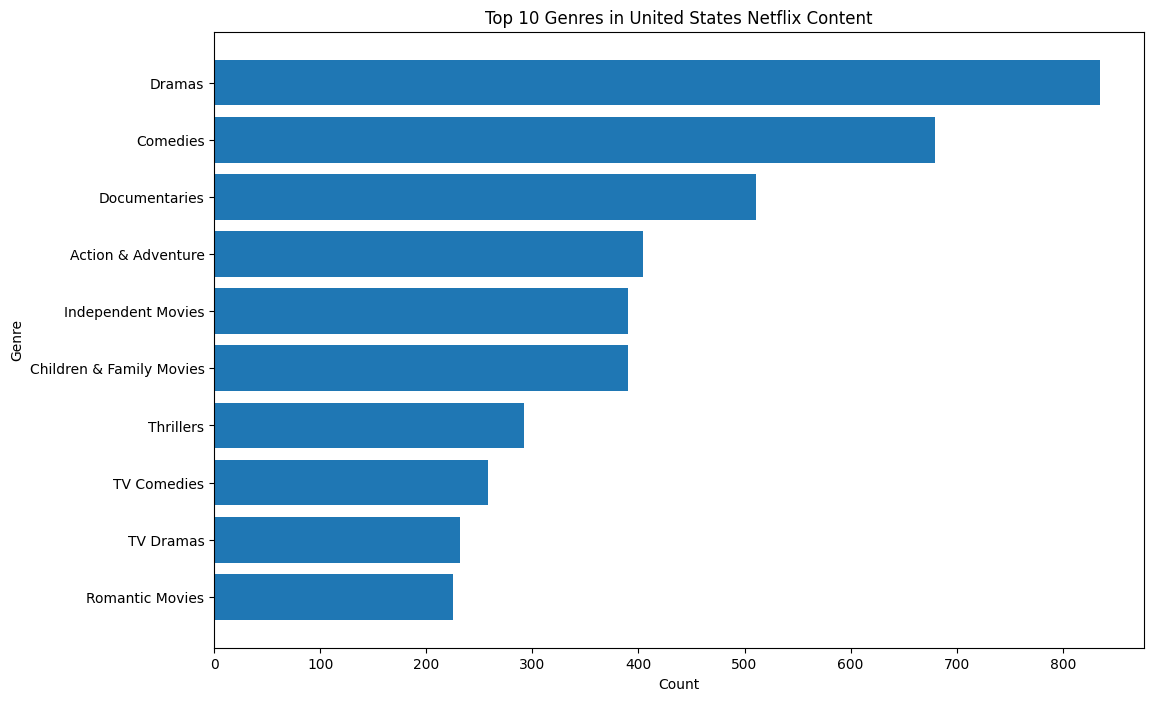

In [233]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.barh(us_genre_top10['listed_in'],us_genre_top10['count'])
plt.title('Top 10 Genres in United States Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/us_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – United States

**Observations**

- Dramas and Comedies represent the largest categories within Netflix’s U.S. content portfolio.
- Documentaries also maintain a substantial presence, suggesting strong investment in nonfiction and educational storytelling.
- Several genres, including Action & Adventure, Independent Movies, and Children & Family Movies, maintain relatively comparable representation levels.

**Business Interpretation**

The U.S. catalog demonstrates a relatively balanced genre distribution across multiple entertainment categories. Rather than relying on a single dominant content type, Netflix appears to maintain a diversified portfolio strategy designed to serve broad audience segments, including family viewers, documentary audiences, and mainstream entertainment consumers.

#### The Indian Netflix catalog is strongly centered around movie-oriented storytelling, particularly dramas and international films. This section examines the dominant genre categories within Netflix content associated with India.

In [234]:
india_genre=genre_by_country_df[genre_by_country_df['country']=='India']
india_genre=india_genre.sort_values(by='count',ascending=False)
india_genre.head(10)


,country,listed_in,count
526,India,International Movies,864
522,India,Dramas,662
517,India,Comedies,323
525,India,Independent Movies,167
513,India,Action & Adventure,137
532,India,Romantic Movies,120
530,India,Music & Musicals,96
547,India,Thrillers,92
527,India,International TV Shows,66
524,India,Horror Movies,35


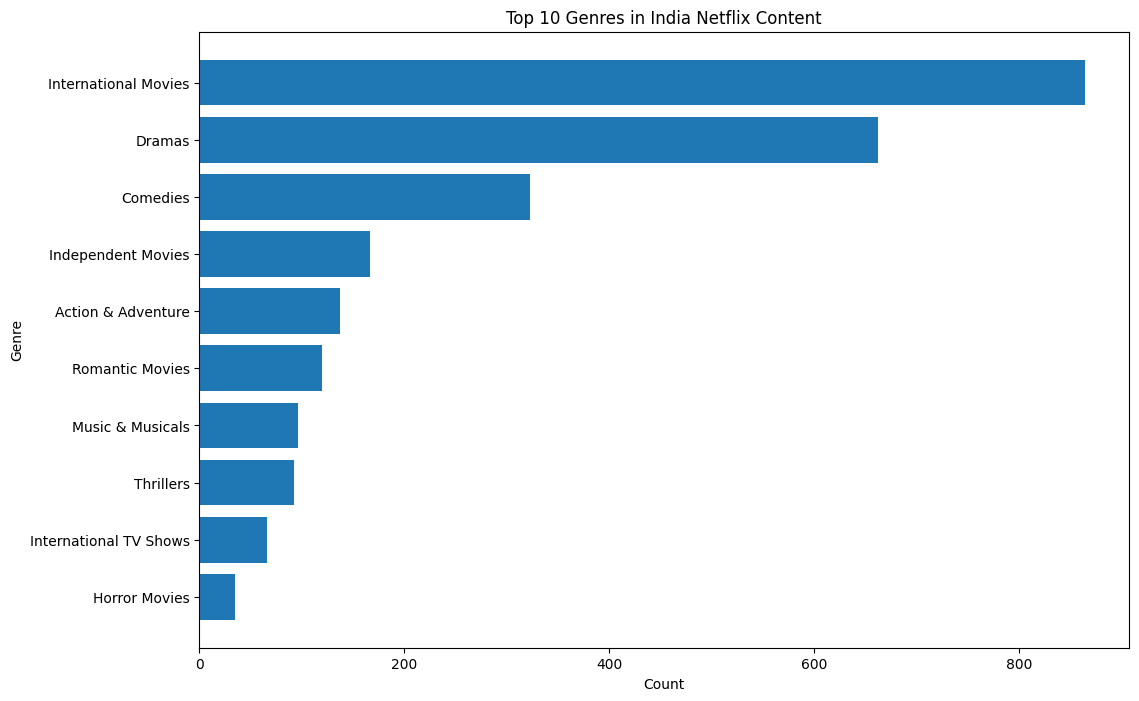

In [235]:
india_genre_top10=india_genre.head(10)
plt.figure(figsize=(12,8))
plt.barh(india_genre_top10['listed_in'],india_genre_top10['count'])
plt.title('Top 10 Genres in India Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/india_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – India

**Observations**

- International Movies and Dramas dominate Netflix’s Indian content catalog by a substantial margin.
- Comedies remain important but appear significantly smaller than the two leading genres.
- Most remaining genres decline rapidly in volume after the top categories.

**Business Interpretation**

The Indian catalog appears highly concentrated in drama-oriented and movie-focused storytelling. Compared with the United States, Netflix’s India-related content strategy may prioritize a smaller set of high-demand genres rather than maintaining broad genre diversification.

#### The United Kingdom maintains a strong television-focused content profile, led by British TV productions and drama-related categories. This analysis explores the leading genres within Netflix’s U.K.-related catalog.

In [236]:
uk_genre=genre_by_country_df[genre_by_country_df['country']=='United Kingdom']
uk_genre=uk_genre.sort_values(by='count',ascending=False)
uk_genre.head(10)

,country,listed_in,count
1300,United Kingdom,British TV Shows,225
1309,United Kingdom,Dramas,196
1313,United Kingdom,International Movies,168
1314,United Kingdom,International TV Shows,128
1307,United Kingdom,Documentaries,127
1304,United Kingdom,Comedies,91
1308,United Kingdom,Docuseries,89
1299,United Kingdom,Action & Adventure,84
1312,United Kingdom,Independent Movies,74
1335,United Kingdom,Thrillers,61


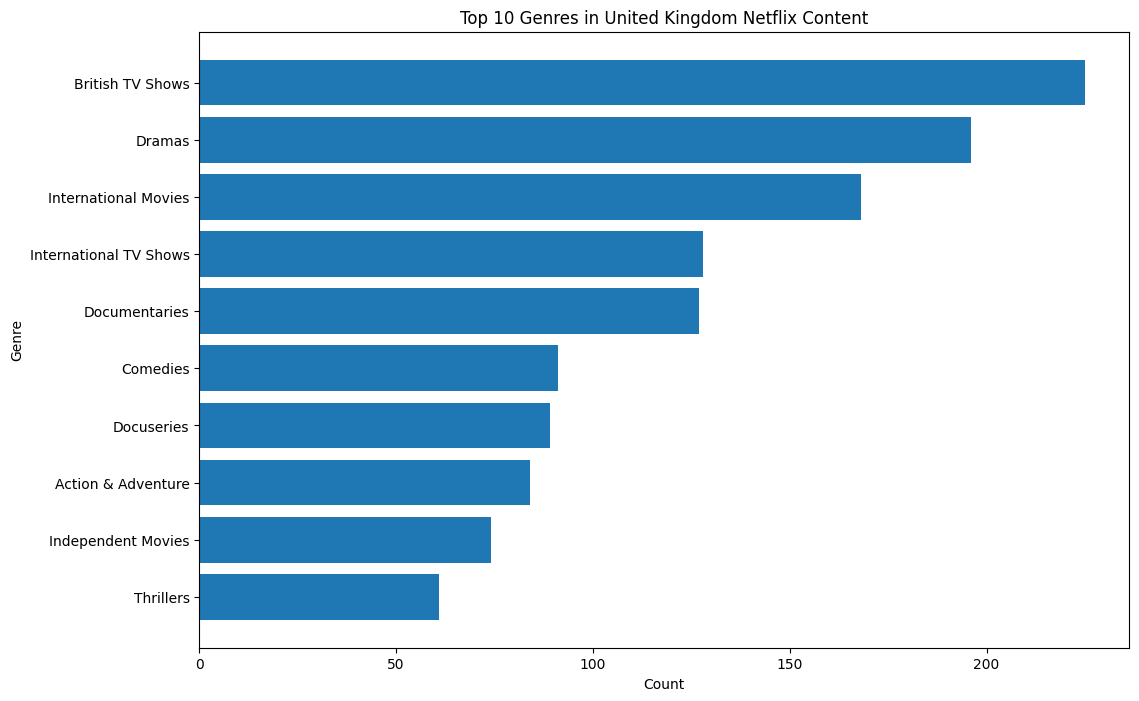

In [237]:
uk_genre_top10=uk_genre.head(10)
plt.figure(figsize=(12,8))
plt.barh(uk_genre_top10['listed_in'],uk_genre_top10['count'])
plt.title('Top 10 Genres in United Kingdom Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/uk_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()


## Key Findings – United Kingdom

**Observations**

- British TV Shows represent the largest category within the U.K. catalog.
- Dramas and International Movies also maintain strong representation.
- Documentaries and International TV Shows occupy meaningful portions of the catalog as well.

**Business Interpretation**

The U.K. catalog shows a strong emphasis on television-oriented storytelling, particularly British-produced TV content. Compared with some other countries, the U.K. portfolio appears more balanced between domestic television identity and internationally distributed content.

#### Japan demonstrates a distinctive content profile characterized by strong representation of anime and serialized television content. This section analyzes the dominant genre categories within Netflix’s Japanese content catalog.

In [238]:
japan_genre=genre_by_country_df[genre_by_country_df['country']=='Japan']
japan_genre=japan_genre.sort_values(by='count',ascending=False)
japan_genre_top10=japan_genre.head(10)
japan_genre_top10
                                    

,country,listed_in,count
663,Japan,International TV Shows,151
650,Japan,Anime Series,143
662,Japan,International Movies,72
649,Japan,Anime Features,61
648,Japan,Action & Adventure,57
664,Japan,Kids' TV,29
659,Japan,Dramas,23
670,Japan,Romantic TV Shows,21
676,Japan,TV Dramas,21
652,Japan,Children & Family Movies,19


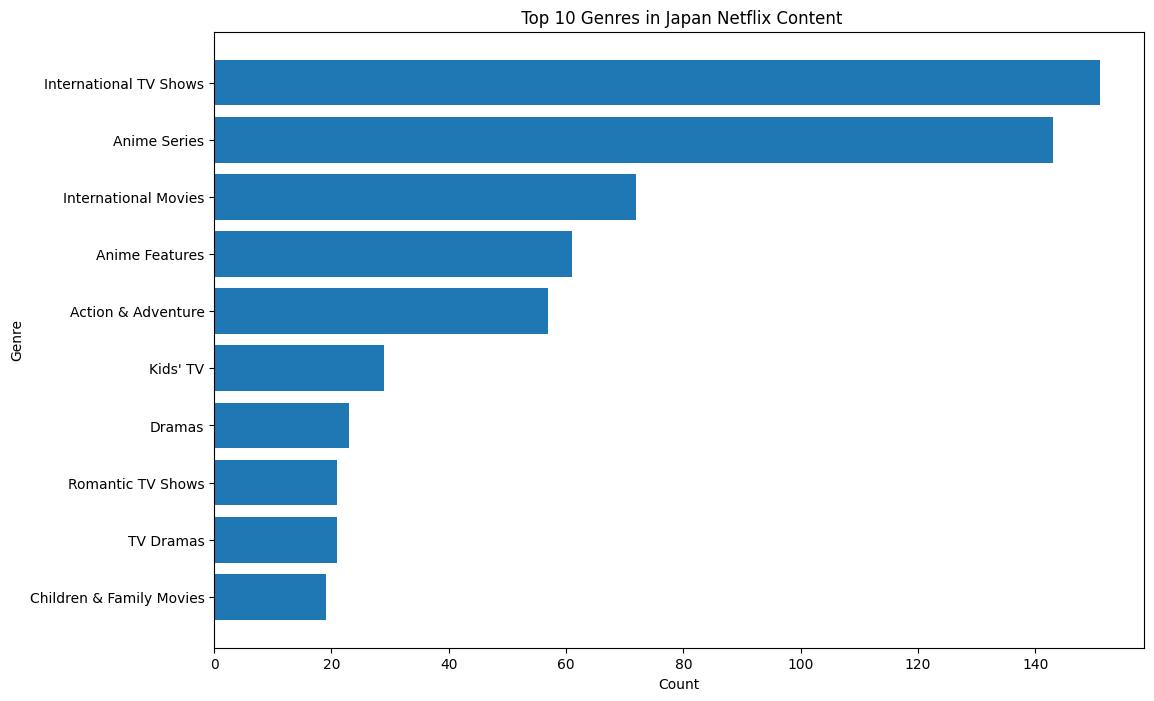

In [239]:
plt.figure(figsize=(12,8))
plt.barh(japan_genre_top10['listed_in'],japan_genre_top10['count'])
plt.title(' Top 10 Genres in Japan Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/japan_gnre_top10',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – Japan

**Observations**

- International TV Shows and Anime Series are the two most represented categories in the Japanese catalog.
- Anime Features also maintain strong representation compared with other countries.
- Traditional drama categories occupy smaller portions of the catalog relative to animation-focused content.

**Business Interpretation**

Japan demonstrates a highly differentiated content profile centered around animation and serialized television content. Rather than competing through broad genre diversification, Japanese content appears to contribute unique niche categories that may attract highly engaged global audiences.

#### South Korea’s Netflix catalog is heavily oriented toward television storytelling, particularly Korean TV shows and romantic series. This analysis examines the leading genres within Netflix content associated with South Korea. 

In [240]:
south_korea_genre=genre_by_country_df[genre_by_country_df['country']=='South Korea']
south_korea_genre=south_korea_genre.sort_values(by='count',ascending=False)
south_korea_genre_top10=south_korea_genre.head(10)
south_korea_genre_top10

,country,listed_in,count
1109,South Korea,International TV Shows,152
1111,South Korea,Korean TV Shows,132
1117,South Korea,Romantic TV Shows,77
1108,South Korea,International Movies,44
1123,South Korea,TV Dramas,38
1105,South Korea,Dramas,26
1102,South Korea,Crime TV Shows,24
1122,South Korea,TV Comedies,19
1101,South Korea,Comedies,17
1099,South Korea,Action & Adventure,17


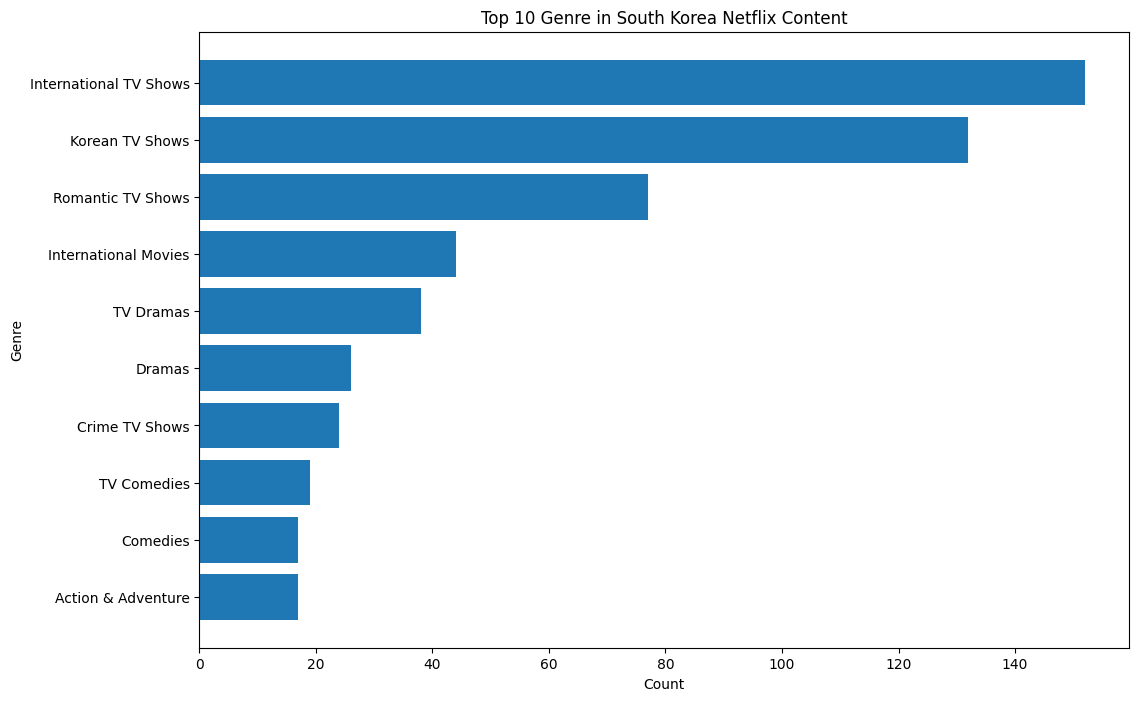

In [241]:
plt.figure(figsize=(12,8))
plt.barh(south_korea_genre_top10['listed_in'],south_korea_genre_top10['count'])
plt.title('Top 10 Genre in South Korea Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/south_korea_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – South Korea

**Observations**

- International TV Shows and Korean TV Shows dominate Netflix’s South Korean content portfolio.
- Romantic TV Shows maintain significantly higher representation than in many other countries.
- Movie-oriented genres occupy a smaller share relative to television-focused categories.

**Business Interpretation**

The South Korean catalog demonstrates a strong specialization in serialized television storytelling. The prominence of Korean TV Shows and Romantic TV content suggests that long-form episodic narratives represent a major strength of South Korea’s global entertainment exports.

#### Canada’s Netflix catalog reflects a relatively balanced mix of entertainment, family-oriented, and movie-focused content categories. This section examines the dominant genres represented within Canadian Netflix content.

In [242]:
canada_genre=genre_by_country_df[genre_by_country_df['country']=='Canada']
canada_genre=canada_genre.sort_values('count',ascending=False)
canada_genre_top10=canada_genre.head(10)
canada_genre_top10

,country,listed_in,count
182,Canada,Comedies,94
187,Canada,Dramas,82
180,Canada,Children & Family Movies,80
193,Canada,Kids' TV,61
191,Canada,International Movies,60
213,Canada,Thrillers,49
190,Canada,Independent Movies,44
177,Canada,Action & Adventure,44
185,Canada,Documentaries,42
189,Canada,Horror Movies,36


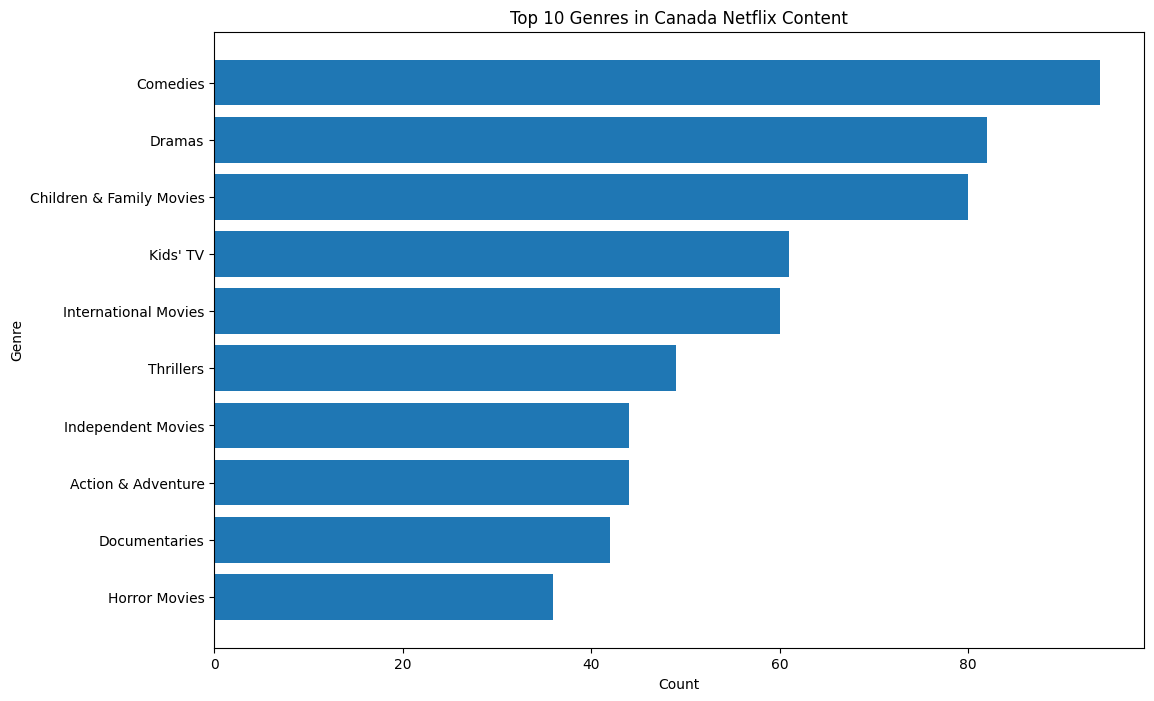

In [243]:
plt.figure(figsize=(12,8))
plt.barh(canada_genre_top10['listed_in'],canada_genre_top10['count'])
plt.title('Top 10 Genres in Canada Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/canada_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

### Key Findings – Canada

**Observations**

- Comedies and Dramas are the largest categories within the Canadian catalog.
- Children & Family Movies and Kids’ TV also maintain substantial representation.
- Genre distribution appears relatively balanced across entertainment, family, and movie-oriented content categories.

**Business Interpretation**

Compared with some more specialized content markets, Canada’s catalog reflects a broader and more balanced content composition. The strong presence of family-oriented genres may indicate a strategy focused on wide demographic accessibility and mainstream audience appeal.

 ## Duration Analysis

This section explores the duration distribution of Netflix movie content.

The analysis aims to investigate:

* overall movie length patterns
* whether Netflix content is concentrated around specific duration ranges
* potential differences between short-form and long-form content strategies

The following visualizations focus on movie duration distributions before expanding into country-level and genre-level duration analysis.

### Movie Duration Distribution 

In [244]:
df_movies=df[df['type']=='Movie'].copy()
df_movies

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016.0
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0


In [245]:
df_movies[['title','type','duration']].head(10)

,title,type,duration
0,Dick Johnson Is Dead,Movie,90 min
6,My Little Pony: A New Generation,Movie,91 min
7,Sankofa,Movie,125 min
9,The Starling,Movie,104 min
12,Je Suis Karl,Movie,127 min
13,Confessions of an Invisible Girl,Movie,91 min
16,Europe's Most Dangerous Man: Otto Skorzeny in ...,Movie,67 min
18,Intrusion,Movie,94 min
22,Avvai Shanmughi,Movie,161 min
23,Go! Go! Cory Carson: Chrissy Takes the Wheel,Movie,61 min


In [246]:
df_movies['duration'].unique()

<StringArray>
[ '90 min',  '91 min', '125 min', '104 min', '127 min',  '67 min',  '94 min',
 '161 min',  '61 min', '166 min',
 ...
  '43 min', '200 min', '196 min', '167 min', '178 min', '228 min',  '18 min',
 '205 min', '201 min', '191 min']
Length: 206, dtype: str

In [247]:
df_movies['duration_minutes']= pd.to_numeric(df_movies['duration'].str.replace('min','',regex=False),errors='coerce')
df_movies[['duration','duration_minutes']].head(20)
df_movies['duration_minutes'].isna().sum()

np.int64(3)

In [248]:
df_movies[df_movies['duration_minutes'].isna()][['title','duration']]

,title,duration
5541,Louis C.K. 2017,NaN
5794,Louis C.K.: Hilarious,NaN
5813,Louis C.K.: Live at the Comedy Store,NaN


In [249]:
df_movies.dropna(subset=['duration_minutes'])

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_year,duration_minutes
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,90.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0,91.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0,125.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0,104.0
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021-09-23,2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,2021.0,127.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8801,s8802,Movie,Zinzana,Majid Al Ansari,"Ali Suliman, Saleh Bakri, Yasa, Ali Al-Jabri, ...","United Arab Emirates, Jordan",2016-03-09,2015,TV-MA,96 min,"Dramas, International Movies, Thrillers",Recovering alcoholic Talal wakes up inside a s...,2016.0,96.0
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,158.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,88.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,88.0


In [250]:
df_movies['duration_minutes'].isna().sum()

np.int64(3)

In [251]:
df_movies = df[df['type'] == 'Movie'].copy()

df_movies['duration_minutes'] = pd.to_numeric(
    df_movies['duration'].str.replace(' min', '', regex=False),
    errors='coerce'
)

df_movies = df_movies.dropna(subset=['duration_minutes'])

df_movies['duration_minutes'].isna().sum()

np.int64(0)

In [252]:
df_movies['duration_minutes'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

In [253]:
df_movies[df_movies['duration_minutes']==3]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_year,duration_minutes
3777,s3778,Movie,Silent,"Limbert Fabian, Brandon Oldenburg",NaN,United States,2019-06-04,2014,TV-Y,3 min,"Children & Family Movies, Sci-Fi & Fantasy","""Silent"" is an animated short film created by ...",2019.0,3.0


In [254]:
df_movies[df_movies['duration_minutes']==312]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_year,duration_minutes
4253,s4254,Movie,Black Mirror: Bandersnatch,NaN,"Fionn Whitehead, Will Poulter, Craig Parkinson...",United States,2018-12-28,2018,TV-MA,312 min,"Dramas, International Movies, Sci-Fi & Fantasy","In 1984, a young programmer begins to question...",2018.0,312.0


In [255]:
import matplotlib.pyplot as plt

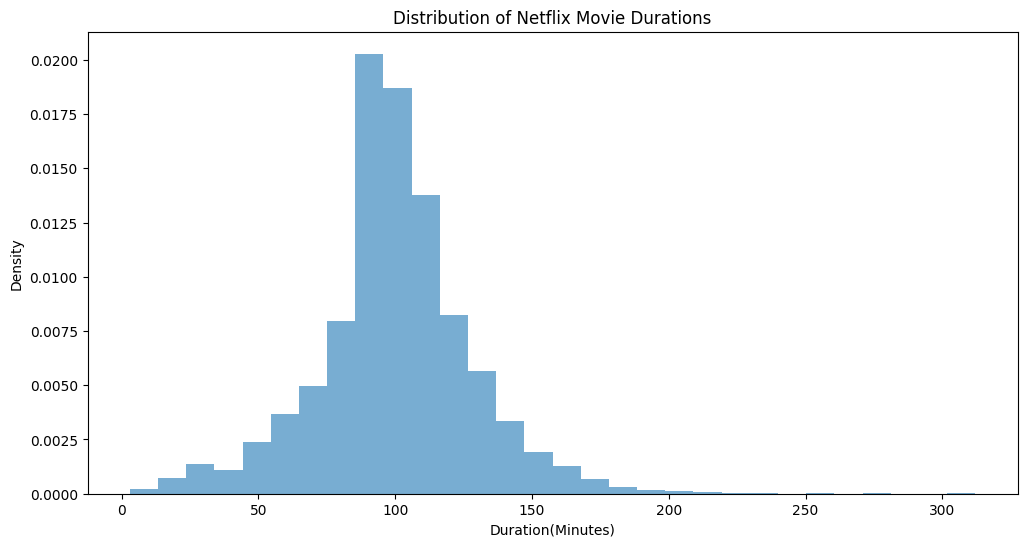

In [293]:
plt.figure(figsize=(12,6))
plt.hist(df_movies['duration_minutes'],bins=30,density=True,alpha=0.6)
plt.title('Distribution of Netflix Movie Durations')
plt.xlabel('Duration(Minutes)')
plt.ylabel('Density')
plt.savefig('figures/movie_duration_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

### Movie Duration Distribution

The histogram shows that Netflix movie durations are concentrated primarily between approximately 80 and 120 minutes, with the distribution peaking around 90–100 minutes. This pattern suggests that most Netflix films follow the conventional feature-length movie format commonly used in commercial film production.

The distribution appears moderately right-skewed, with a small number of very long films extending beyond 180 minutes. While extremely short and extremely long movies exist in the catalog, they represent only a small proportion of total content.

The summary statistics further support this observation:

* Mean duration: approximately 100 minutes
* Median duration: 98 minutes
* Interquartile range: approximately 87–114 minutes

The relatively close mean and median values indicate that the overall duration distribution is fairly stable despite the presence of several long-duration outliers.

These findings suggest that Netflix movie content remains strongly centered around traditional full-length film structures rather than heavily favoring either short-form or ultra-long-form movie formats.


## Rating Distribution Analysis

This section explores the distribution of content ratings in the Netflix catalog.

Unlike user review scores, Netflix ratings represent audience suitability classifications that indicate the intended maturity level of content.

The analysis aims to investigate:

* the overall audience targeting strategy reflected in the catalog
* the relative prevalence of mature versus family-oriented content
* potential differences in content positioning across audience groups

Understanding rating distributions provides a foundation for subsequent analyses of duration, genre, and audience segmentation.

In [257]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [258]:
df['rating'].value_counts(normalize=True)

rating
TV-MA       0.364308
TV-14       0.245371
TV-PG       0.098035
R           0.090765
PG-13       0.055663
TV-Y7       0.037942
TV-Y        0.034874
PG          0.032603
TV-G        0.024991
NR          0.009088
G           0.004658
TV-Y7-FV    0.000682
NC-17       0.000341
UR          0.000341
74 min      0.000114
84 min      0.000114
66 min      0.000114
Name: proportion, dtype: float64

In [259]:
df=df[~df['rating'].str.contains('min',na=False)]
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

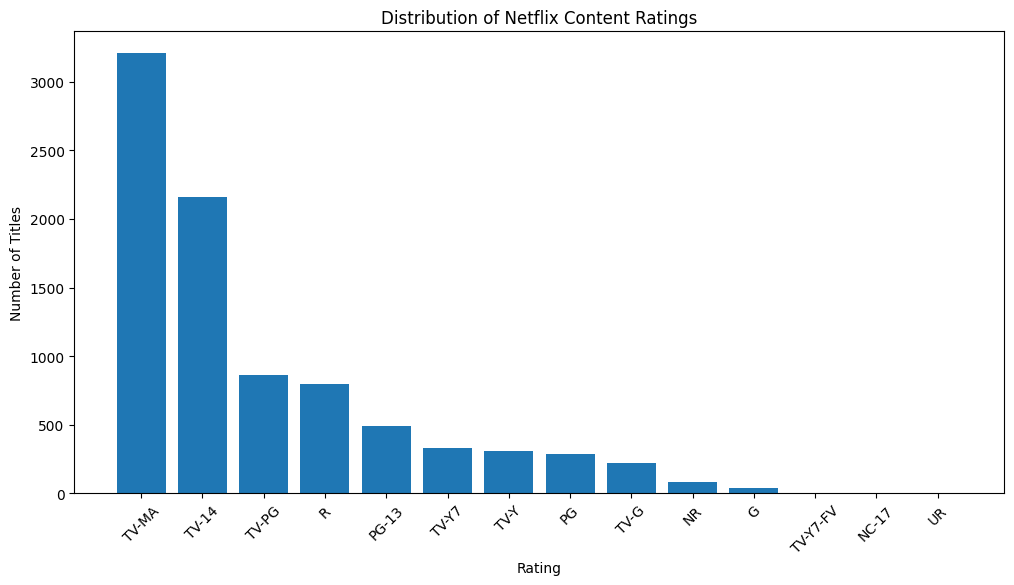

In [292]:
rating_counts=df['rating'].value_counts()
plt.figure(figsize=(12,6))
plt.bar(rating_counts.index,rating_counts.values)
plt.title('Distribution of Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.savefig('figures/content_rating_distribution.png',dpi=300,bbox_inches='tight')
plt.show()

### Rating Distribution Analysis

The rating distribution shows that Netflix content is heavily concentrated in mature-audience categories, particularly TV-MA and TV-14.

TV-MA content represents the largest portion of the catalog by a substantial margin, suggesting that Netflix strongly emphasizes mature audience targeting. TV-14 content also occupies a significant share of the catalog, indicating a secondary focus on teenage and young adult viewers.

In contrast, family-oriented and children-oriented ratings such as TV-Y, TV-Y7, G, and TV-G appear much less frequently. This suggests that Netflix's overall catalog strategy is not primarily centered on young children or family-only entertainment.

The distribution therefore indicates that Netflix content positioning is largely oriented toward adult and adolescent audiences rather than broad all-age programming.

It is important to note that these ratings represent audience suitability classifications rather than viewer review scores. As a result, the analysis reflects platform-level audience targeting patterns rather than content quality evaluation.

In [261]:
rating_duration=df_movies.groupby('rating')['duration_minutes'].mean().sort_values(ascending=False)
rating_duration

rating
NC-17       125.000000
TV-14       110.290820
PG-13       108.330612
R           106.720201
UR          106.333333
PG           98.282230
TV-MA        95.889913
TV-PG        94.851852
NR           94.533333
G            90.268293
TV-G         79.666667
TV-Y7-FV     68.400000
TV-Y7        66.287770
TV-Y         48.114504
Name: duration_minutes, dtype: float64

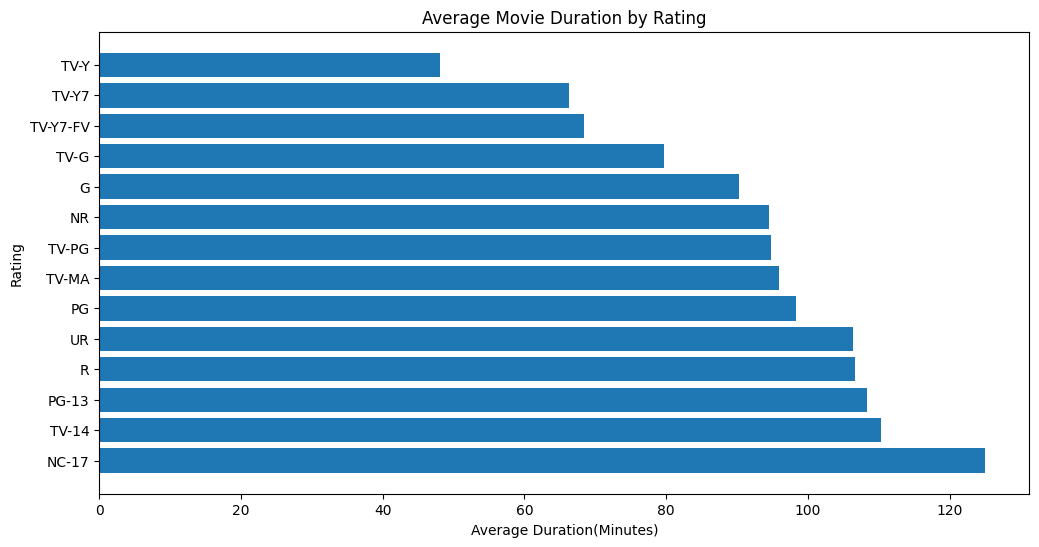

In [291]:
plt.figure(figsize=(12,6))
plt.barh(rating_duration.index,rating_duration.values)
plt.title('Average Movie Duration by Rating')
plt.xlabel('Average Duration(Minutes)')
plt.ylabel('Rating')
plt.savefig('figures/average_movie_duration_by_rating.png',dpi=300,bbox_inches='tight')
plt.show()


### Duration and Rating Analysis

The relationship between movie duration and content rating reveals noticeable differences across audience-targeting categories.

Children-oriented ratings such as TV-Y and TV-Y7 show substantially shorter average durations compared with more mature audience categories. TV-Y content, in particular, has the shortest average duration in the catalog, suggesting that Netflix children's programming tends to favor shorter viewing formats and faster consumption patterns.

In contrast, ratings associated with mature and adolescent audiences — including TV-14, PG-13, and R — display noticeably longer average durations. TV-14 content shows one of the highest average durations among the major rating categories, indicating that Netflix may invest more heavily in longer-form storytelling for teenage and adult audiences.

The results suggest that audience maturity classification is associated not only with content suitability, but also with structural differences in content length. Family-oriented and children's programming appear more compact, while mature-audience content tends to follow more traditional full-length film formats.

It is important to note that several rating categories such as NC-17 and UR contain relatively few titles, so their average durations may be less stable and should be interpreted cautiously.

<Figure size 1200x600 with 0 Axes>

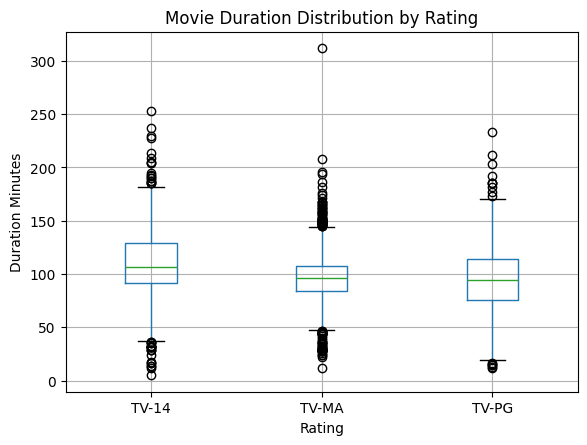

In [290]:
top_ratings=['TV-MA','TV-14','TV-PG']
df_top_ratings=df_movies[df_movies['rating'].isin(top_ratings)]
plt.figure(figsize=(12,6))
df_top_ratings.boxplot(column='duration_minutes',by='rating')
plt.title('Movie Duration Distribution by Rating')
plt.suptitle('')
plt.xlabel("Rating")
plt.ylabel('Duration Minutes')
plt.savefig('figures/movie_duration_distribution_by_rating.png',dpi=300,bbox_inches='tight')
plt.show()



### Duration Distribution Across Major Rating Categories

The boxplots reveal noticeable differences in movie duration distributions across major audience rating categories, particularly among TV-MA, TV-14, and TV-PG content.

Although the median movie durations across these categories remain relatively similar and generally fall within the conventional feature-length range, the overall spread and variability differ substantially. TV-MA content exhibits the widest distribution and the largest number of outliers, suggesting that mature-audience programming on Netflix allows for a broader range of runtime structures.

The large number of outliers observed in the distributions does not necessarily indicate data quality problems. Instead, these outliers likely reflect the diversity of content formats available on streaming platforms, including extended documentaries, stand-up specials, experimental films, and other non-traditional productions.

Compared with more family-oriented categories such as TV-PG, mature-audience content appears to tolerate greater runtime variability and more frequent long-duration titles. This pattern may indicate that Netflix adopts a more flexible content-length strategy for adult audiences, while younger audience categories remain more standardized and compact in duration structure.

Importantly, boxplots remain informative despite the presence of many outliers because they rely primarily on robust statistics such as the median and interquartile range rather than the arithmetic mean alone. As a result, the visualization continues to provide meaningful insight into the central tendency and variability of content duration across audience segments.

## Qustion: What types of audiences are different genres primarily targeting?

In [264]:
df_genre_rating=df_movies[['title','listed_in','rating']].copy()

In [265]:
df_genre_rating['listed_in'].head(10)

0                                        Documentaries
6                             Children & Family Movies
7     Dramas, Independent Movies, International Movies
9                                     Comedies, Dramas
12                        Dramas, International Movies
13                  Children & Family Movies, Comedies
16                 Documentaries, International Movies
18                                           Thrillers
22                      Comedies, International Movies
23                            Children & Family Movies
Name: listed_in, dtype: str

In [266]:
df_genre_rating=df_genre_rating.dropna(subset=['listed_in','rating'])


In [267]:
df_genre_rating['listed_in']=df_genre_rating['listed_in'].str.split(', ')

In [268]:
df_genre_rating=df_genre_rating.explode('listed_in')

In [269]:
genre_rating_counts=df_genre_rating.groupby(['listed_in','rating']).size().reset_index()

In [270]:
genre_rating_counts=genre_rating_counts.rename(columns={0:'count'})
print(genre_rating_counts.head(10))

            listed_in    rating  count
0  Action & Adventure         G      1
1  Action & Adventure        NR      9
2  Action & Adventure        PG     32
3  Action & Adventure     PG-13    148
4  Action & Adventure         R    220
5  Action & Adventure     TV-14    213
6  Action & Adventure     TV-MA    201
7  Action & Adventure     TV-PG     33
8  Action & Adventure  TV-Y7-FV      1
9  Action & Adventure        UR      1


In [271]:
top_genres=df_genre_rating['listed_in'].value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: count, dtype: int64

In [272]:
df_genre_rating = df_movies[
    ['title', 'listed_in', 'rating']
].copy()

df_genre_rating = df_genre_rating.dropna(
    subset=['listed_in', 'rating']
)

df_genre_rating['listed_in'] = (
    df_genre_rating['listed_in']
    .str.split(', ')
)

df_genre_rating = (
    df_genre_rating
    .explode('listed_in')
)

print(df_genre_rating.shape)

print(df_genre_rating.head())

(13185, 3)
                              title                 listed_in rating
0              Dick Johnson Is Dead             Documentaries  PG-13
6  My Little Pony: A New Generation  Children & Family Movies     PG
7                           Sankofa                    Dramas  TV-MA
7                           Sankofa        Independent Movies  TV-MA
7                           Sankofa      International Movies  TV-MA


In [273]:
df_genre_rating.columns

Index(['title', 'listed_in', 'rating'], dtype='str')

In [274]:
df_genre_rating['listed_in'].apply(type).value_counts()
df_genre_rating['rating'].apply(type).value_counts()

rating
<class 'str'>    13185
Name: count, dtype: int64

In [275]:
genre_rating_pivot = (
    df_genre_rating
    .groupby(['listed_in', 'rating'])
    .size()
    .unstack(fill_value=0)
)

genre_rating_pivot.head()

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
listed_in,,,,,,,,,,,,,,
Action & Adventure,1,0,9,32,148,220,213,0,201,33,0,0,1,1
Anime Features,0,0,0,5,4,0,23,1,15,19,0,4,0,0
Children & Family Movies,33,0,0,195,11,0,18,51,1,85,113,129,5,0
Classic Movies,8,0,3,17,10,32,23,1,11,11,0,0,0,0
Comedies,11,2,14,148,168,180,465,29,431,153,21,47,4,1


In [276]:
top_genres=df_genre_rating['listed_in'].value_counts().head(10)
top10_genre_names=top_genres.index
top10_genre_names

Index(['International Movies', 'Dramas', 'Comedies', 'Documentaries',
       'Action & Adventure', 'Independent Movies', 'Children & Family Movies',
       'Romantic Movies', 'Thrillers', 'Music & Musicals'],
      dtype='str', name='listed_in')

In [277]:
top10_rating=genre_rating_pivot.loc[top10_genre_names]
top10_rating.head()

rating,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
listed_in,,,,,,,,,,,,,,
International Movies,1,2,34,13,54,101,1065,54,1130,294,1,1,0,2
Dramas,6,1,27,69,192,375,693,27,830,200,3,1,0,2
Comedies,11,2,14,148,168,180,465,29,431,153,21,47,4,1
Documentaries,5,0,22,20,33,27,227,47,321,167,0,0,0,0
Action & Adventure,1,0,9,32,148,220,213,0,201,33,0,0,1,1


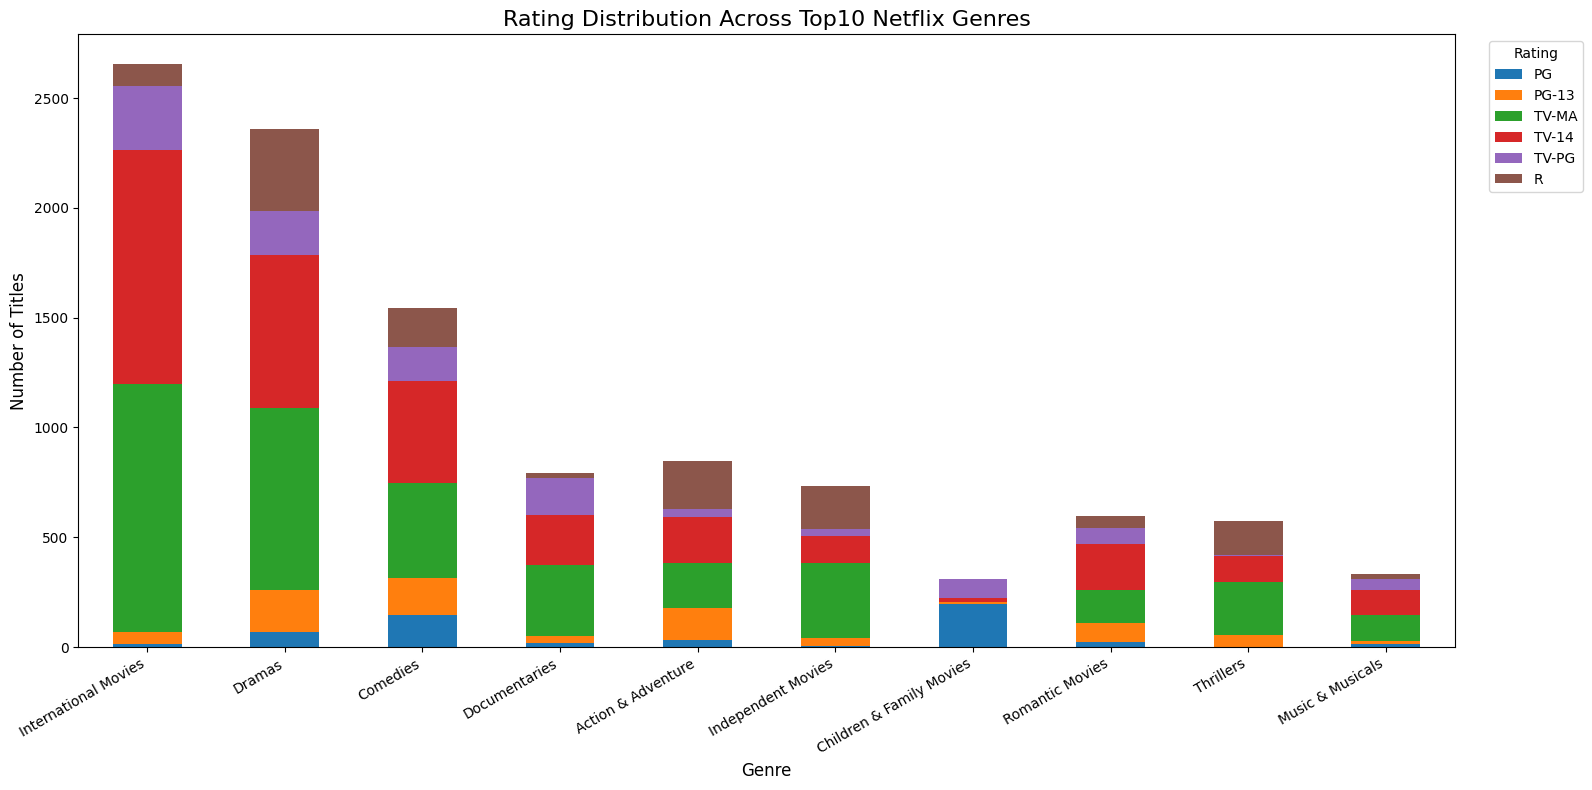

In [294]:
major_ratings=['PG','PG-13','TV-MA','TV-14','TV-PG','R']
top10_major_rating=top10_rating[major_ratings]
top10_major_rating.plot(kind='bar',stacked=True,figsize=(16,8))
plt.title('Rating Distribution Across Top10 Netflix Genres',fontsize=16)
plt.xlabel('Genre',fontsize=12)
plt.ylabel('Number of Titles',fontsize=12)
plt.xticks(rotation=30,ha='right')
plt.legend(title='Rating',bbox_to_anchor=(1.02,1),loc='upper left')
plt.tight_layout()
plt.savefig('figures/top10_genres_rating_distribution.png',dpi=300,bbox_inches='tight')
plt.show()


## Rating Distribution Across Top 10 Netflix Genres

This stacked bar chart shows the rating distribution across the top 10 most common Netflix genres. Several interesting content strategy patterns can be observed from the visualization.

### Key Findings

- **International Movies** and **Dramas** are the two largest genre categories on Netflix, significantly exceeding other genres in total title count.

- Across most major genres, **TV-MA** and **TV-14** dominate the rating distribution, suggesting that Netflix primarily targets teen and adult audiences rather than children.

- **Children & Family Movies** show a very different pattern compared to other genres, with much higher proportions of **PG** and **TV-PG** ratings. This reflects Netflix’s family-oriented and child-friendly content strategy within this category.

- Genres such as **Thrillers**, **Documentaries**, and **Independent Movies** contain especially high proportions of mature ratings, indicating stronger emphasis on adult-oriented storytelling and complex themes.

- **Comedies** demonstrate a relatively balanced distribution across multiple ratings, suggesting that comedic content is produced for a wider range of audience groups.

### Business Insight

The analysis suggests that Netflix’s overall content strategy is heavily focused on mature and globally distributed entertainment content. The dominance of TV-MA and TV-14 ratings across multiple genres indicates that adult audiences remain Netflix’s primary target market.

At the same time, the platform maintains diversified audience segmentation by offering family-friendly content within specific genres such as Children & Family Movies.

## Netflix Content Age Analysis

In [279]:
df['added_year']=df['date_added'].dt.year
df['content_age']=df['added_year']-df['release_year']
df[['title','added_year','release_year','content_age']].head(10)

,title,added_year,release_year,content_age
0,Dick Johnson Is Dead,2021.0,2020,1.0
1,Blood & Water,2021.0,2021,0.0
2,Ganglands,2021.0,2021,0.0
3,Jailbirds New Orleans,2021.0,2021,0.0
4,Kota Factory,2021.0,2021,0.0
5,Midnight Mass,2021.0,2021,0.0
6,My Little Pony: A New Generation,2021.0,2021,0.0
7,Sankofa,2021.0,1993,28.0
8,The Great British Baking Show,2021.0,2021,0.0
9,The Starling,2021.0,2021,0.0


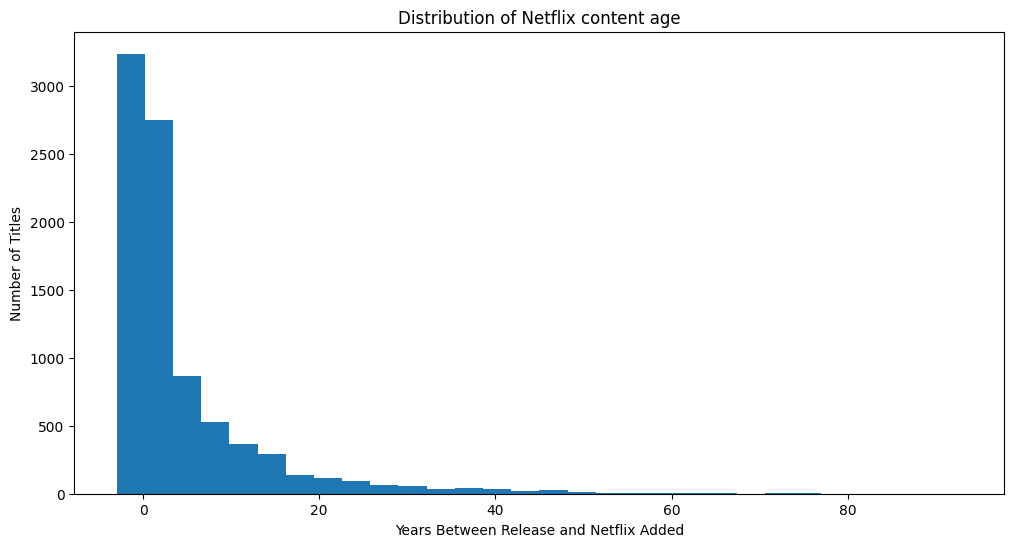

In [280]:
plt.figure(figsize=(12,6))
plt.hist(df['content_age'].dropna(),bins=30)
plt.title('Distribution of Netflix content age')
plt.xlabel('Years Between Release and Netflix Added')
plt.ylabel('Number of Titles')
plt.savefig('figures/content_age_distribution.png',dpi=30,bbox_inches='tight')
plt.show()

In [281]:
df['content_age'].mean()

np.float64(4.691706868826097)

In [282]:
df['content_age'].median()

np.float64(1.0)

In [283]:
df.groupby('type')['content_age'].median()

type
Movie      2.0
TV Show    0.0
Name: content_age, dtype: float64


### Key Findings

- Most Netflix titles were added to the platform within a relatively short period after their original release dates. The distribution is heavily concentrated within the first few years, indicating a strong preference for newer content.

- The content age distribution is right-skewed, with a small number of much older titles extending the tail of the distribution. This suggests that while Netflix mainly prioritizes recent releases, the platform also maintains a smaller catalog of classic or legacy content.

- The median content age is lower than the mean content age, further confirming the presence of older titles that increase the overall average.

- TV Shows generally appear to have lower average content age compared to Movies, suggesting that Netflix tends to add television series more quickly after release. This likely reflects the platform’s emphasis on user retention and binge-watching behavior through serialized content.

### Business Insight

The results suggest that Netflix’s content acquisition strategy is strongly oriented toward recently released content, which helps maintain platform freshness and user engagement. At the same time, the presence of older catalog titles indicates that Netflix also preserves a curated selection of classic content to diversify its library and attract broader audience segments.

The faster addition cycle observed for TV Shows may reflect the growing strategic importance of episodic content in driving long-term viewer retention and platform engagement.